<a href="https://colab.research.google.com/github/wanchenlang-max/econ5200-assignments/blob/main/assignment5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install wbgapi scikit-learn statsmodels matplotlib seaborn pandas numpy

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wbgapi as wb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, lasso_path, LogisticRegression
from sklearn.metrics import (
    r2_score, mean_squared_error, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score,
    accuracy_score
)

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)

SEED = 42
YEARS = range(2013, 2020)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def count_nonzero(coefs, tol=1e-8):
    return int(np.sum(np.abs(coefs) > tol))

In [4]:
indicator_map = {
    "NY.GDP.PCAP.KD.ZG": "gdp_growth_pc",

    "NE.GDI.TOTL.ZS": "gross_capital_formation_pct_gdp",
    "NE.CON.GOVT.ZS": "gov_consumption_pct_gdp",
    "NE.CON.PRVT.ZS": "private_consumption_pct_gdp",
    "NE.EXP.GNFS.ZS": "exports_pct_gdp",
    "NE.IMP.GNFS.ZS": "imports_pct_gdp",
    "NE.TRD.GNFS.ZS": "trade_pct_gdp",
    "BX.KLT.DINV.WD.GD.ZS": "fdi_inflows_pct_gdp",
    "BX.TRF.PWKR.DT.GD.ZS": "remittances_pct_gdp",
    "BN.CAB.XOKA.GD.ZS": "current_account_pct_gdp",
    "FM.LBL.BMNY.GD.ZS": "broad_money_pct_gdp",
    "FS.AST.PRVT.GD.ZS": "private_credit_pct_gdp",
    "FS.AST.DOMS.GD.ZS": "domestic_credit_financial_sector_pct_gdp",
    "GC.DOD.TOTL.GD.ZS": "gov_debt_pct_gdp",
    "GC.TAX.TOTL.GD.ZS": "tax_revenue_pct_gdp",
    "MS.MIL.XPND.GD.ZS": "military_spending_pct_gdp",
    "FP.CPI.TOTL.ZG": "inflation_cpi",
    "FR.INR.RINR": "real_interest_rate",
    "SL.UEM.TOTL.ZS": "unemployment_pct",
    "SP.POP.GROW": "population_growth",
    "SP.DYN.LE00.IN": "life_expectancy",
    "SP.DYN.TFRT.IN": "fertility_rate",
    "SE.SEC.ENRR": "secondary_enrollment",
    "SE.TER.ENRR": "tertiary_enrollment",
    "SH.XPD.CHEX.GD.ZS": "health_spending_pct_gdp",
    "IT.NET.USER.ZS": "internet_users_pct",
    "EN.ATM.CO2E.PC": "co2_per_capita",
    "EG.USE.PCAP.KG.OE": "energy_use_per_capita",
    "AG.LND.AGRI.ZS": "agri_land_pct",
    "NV.AGR.TOTL.ZS": "agriculture_value_added_pct_gdp",
    "NV.IND.TOTL.ZS": "industry_value_added_pct_gdp",
    "NV.SRV.TOTL.ZS": "services_value_added_pct_gdp",
}

econ_meta = wb.economy.DataFrame().reset_index()
if "economy" not in econ_meta.columns:
    econ_meta = econ_meta.rename(columns={econ_meta.columns[0]: "economy"})

country_codes = econ_meta[econ_meta["aggregate"] == False]["economy"].astype(str).tolist()

raw = wb.data.DataFrame(
    list(indicator_map.keys()),
    economy=country_codes,
    time=YEARS,
    skipBlanks=False,
    columns="series"
).reset_index()

if "time" not in raw.columns:
    raw = raw.rename(columns={raw.columns[1]: "time"})

raw["year"] = raw["time"].astype(str).str.replace("YR", "", regex=False).astype(int)

available_series = [c for c in indicator_map if c in raw.columns]
missing_series = sorted(set(indicator_map) - set(available_series))

print("Requested indicators:", len(indicator_map))
print("Returned indicators :", len(available_series))
if len(missing_series) > 0:
    print("Missing from API response:", missing_series)

rename_dict = {k: v for k, v in indicator_map.items() if k in raw.columns}
raw = raw.rename(columns=rename_dict)

name_candidates = [c for c in econ_meta.columns if c.lower() in ["name", "value", "country", "economy_name"]]
country_name_col = name_candidates[0] if len(name_candidates) > 0 else None

if country_name_col is not None:
    raw = raw.merge(econ_meta[["economy", country_name_col]], on="economy", how="left")
    raw = raw.rename(columns={country_name_col: "country_name"})
else:
    raw["country_name"] = raw["economy"]

country_level = raw.groupby(["economy", "country_name"], as_index=False)[list(rename_dict.values())].mean()

outcome = "gdp_growth_pc"
all_features = [v for v in rename_dict.values() if v != outcome]

df = country_level[["economy", "country_name", outcome] + all_features].copy()

df = df.dropna(subset=[outcome]).copy()

missing_rate_feature = df[all_features].isna().mean().sort_values(ascending=False)
keep_features = missing_rate_feature[missing_rate_feature <= 0.40].index.tolist()
drop_features = missing_rate_feature[missing_rate_feature > 0.40].index.tolist()

df = df[["economy", "country_name", outcome] + keep_features].copy()

country_missing_rate = df[keep_features].isna().mean(axis=1)
df = df.loc[country_missing_rate <= 0.40].copy()

missing_rate_feature_2 = df[keep_features].isna().mean()
keep_features = missing_rate_feature_2[missing_rate_feature_2 <= 0.40].index.tolist()

df = df[["economy", "country_name", outcome] + keep_features].copy()

for col in keep_features:
    df[col] = df[col].fillna(df[col].median())

df["crisis"] = (df[outcome] < 0).astype(int)

print("\nFinal dataset shape:", df.shape)
print("Predictor count:", len(keep_features))
print("Dropped high-missing indicators:", drop_features)
print("\nCrisis counts:")
print(df["crisis"].value_counts().sort_index().rename(index={0: "No Crisis", 1: "Crisis"}))
print("\nOverall crisis base rate:", round(df["crisis"].mean(), 4))

X = df[keep_features].copy()
y_reg = df[outcome].copy()
y_clf = df["crisis"].copy()
meta = df[["economy", "country_name"]].copy()

(
    X_train, X_test,
    y_train_reg, y_test_reg,
    y_train_clf, y_test_clf,
    meta_train, meta_test
) = train_test_split(
    X, y_reg, y_clf, meta,
    test_size=0.30,
    random_state=SEED,
    stratify=y_clf
)

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X.columns,
    index=X_test.index
)

print("\nTrain shape:", X_train_scaled.shape)
print("Test shape :", X_test_scaled.shape)
print("Train crisis rate:", round(y_train_clf.mean(), 4))
print("Test crisis rate :", round(y_test_clf.mean(), 4))

Requested indicators: 32
Returned indicators : 31
Missing from API response: ['EN.ATM.CO2E.PC']

Final dataset shape: (197, 32)
Predictor count: 28
Dropped high-missing indicators: ['domestic_credit_financial_sector_pct_gdp', 'gov_debt_pct_gdp']

Crisis counts:
crisis
No Crisis    161
Crisis        36
Name: count, dtype: int64

Overall crisis base rate: 0.1827

Train shape: (137, 28)
Test shape : (60, 28)
Train crisis rate: 0.1825
Test crisis rate : 0.1833


In [5]:
ols_reg = LinearRegression()
ols_reg.fit(X_train_scaled, y_train_reg)

yhat_train_ols = ols_reg.predict(X_train_scaled)
yhat_test_ols = ols_reg.predict(X_test_scaled)

ols_train_r2 = r2_score(y_train_reg, yhat_train_ols)
ols_test_r2 = r2_score(y_test_reg, yhat_test_ols)
ols_gap = ols_train_r2 - ols_test_r2

p = X_train_scaled.shape[1]
n = X_train_scaled.shape[0]
p_over_n = p / n

print("=== Step 1.1: OLS Overfitting ===")
print(f"Training R^2      : {ols_train_r2:.4f}")
print(f"Test R^2          : {ols_test_r2:.4f}")
print(f"Train-Test R^2 gap: {ols_gap:.4f}")
print(f"p/n ratio         : {p_over_n:.4f}  ({p} predictors / {n} training observations)")

response_11 = f"""
Written response:
The OLS model shows a train-test R^2 gap of {ols_gap:.4f}, which is a classic sign of overfitting:
it fits the training data much better than unseen test countries. With p/n = {p_over_n:.4f},
the model is trying to estimate many coefficients relative to the number of training observations,
so variance rises and OLS becomes unstable. In bias-variance terms, OLS keeps bias low but pays for it
with very high variance because too many degrees of freedom are being used.
"""
print(response_11)

=== Step 1.1: OLS Overfitting ===
Training R^2      : 0.6502
Test R^2          : -0.9005
Train-Test R^2 gap: 1.5507
p/n ratio         : 0.2044  (28 predictors / 137 training observations)

Written response:
The OLS model shows a train-test R^2 gap of 1.5507, which is a classic sign of overfitting:
it fits the training data much better than unseen test countries. With p/n = 0.2044,
the model is trying to estimate many coefficients relative to the number of training observations,
so variance rises and OLS becomes unstable. In bias-variance terms, OLS keeps bias low but pays for it
with very high variance because too many degrees of freedom are being used.



In [6]:
alphas_grid = np.logspace(-4, 4, 200)

ridge_cv = RidgeCV(alphas=alphas_grid, cv=5)
ridge_cv.fit(X_train_scaled, y_train_reg)

lasso_cv = LassoCV(cv=5, random_state=SEED, max_iter=20000, n_alphas=200)
lasso_cv.fit(X_train_scaled, y_train_reg)

# Ridge metrics
ridge_train_pred = ridge_cv.predict(X_train_scaled)
ridge_test_pred = ridge_cv.predict(X_test_scaled)

ridge_train_r2 = r2_score(y_train_reg, ridge_train_pred)
ridge_test_r2 = r2_score(y_test_reg, ridge_test_pred)
ridge_test_rmse = rmse(y_test_reg, ridge_test_pred)

# Lasso metrics
lasso_train_pred = lasso_cv.predict(X_train_scaled)
lasso_test_pred = lasso_cv.predict(X_test_scaled)

lasso_train_r2 = r2_score(y_train_reg, lasso_train_pred)
lasso_test_r2 = r2_score(y_test_reg, lasso_test_pred)
lasso_test_rmse = rmse(y_test_reg, lasso_test_pred)

# OLS RMSE for comparison
ols_test_rmse = rmse(y_test_reg, yhat_test_ols)

comparison_df = pd.DataFrame([
    {
        "Model": "OLS",
        "Lambda_alpha": np.nan,
        "Nonzero_Predictors": X_train_scaled.shape[1],
        "Training_R2": ols_train_r2,
        "Test_R2": ols_test_r2,
        "Test_RMSE": ols_test_rmse,
    },
    {
        "Model": "Ridge",
        "Lambda_alpha": ridge_cv.alpha_,
        "Nonzero_Predictors": count_nonzero(ridge_cv.coef_),
        "Training_R2": ridge_train_r2,
        "Test_R2": ridge_test_r2,
        "Test_RMSE": ridge_test_rmse,
    },
    {
        "Model": "Lasso",
        "Lambda_alpha": lasso_cv.alpha_,
        "Nonzero_Predictors": count_nonzero(lasso_cv.coef_),
        "Training_R2": lasso_train_r2,
        "Test_R2": lasso_test_r2,
        "Test_RMSE": lasso_test_rmse,
    }
])

comparison_df = comparison_df.sort_values(["Test_R2", "Test_RMSE"], ascending=[False, True]).reset_index(drop=True)

print("=== Step 1.2: Model Comparison ===")
print(f"Ridge alpha*: {ridge_cv.alpha_:.6f}")
print(f"Lasso alpha*: {lasso_cv.alpha_:.6f}\n")
print(comparison_df.round(4))

best_model = comparison_df.iloc[0]["Model"]

lasso_coef = pd.Series(lasso_cv.coef_, index=X.columns)
selected_features = lasso_coef[lasso_coef.abs() > 1e-8].index.tolist()

if len(selected_features) == 0:
    selected_features = lasso_coef.abs().sort_values(ascending=False).head(5).index.tolist()
    print("\nWarning: Lasso selected 0 features at the strict threshold, so top 5 coefficients were used as fallback.")

print("\nLasso-selected features:")
print(selected_features)

response_12 = f"""
Written response:
I would recommend {best_model} for operational GDP growth forecasting because it gives the strongest
out-of-sample performance in the comparison table. Ridge shrinks all coefficients toward zero, which
adds some bias but can sharply reduce variance; Lasso does the same while also setting some coefficients
exactly to zero, which raises bias further but improves simplicity and interpretability. Compared with OLS,
both methods trade a little bias for a meaningful gain in stability on new countries.
"""
print(response_12)

=== Step 1.2: Model Comparison ===
Ridge alpha*: 15.343684
Lasso alpha*: 0.001705

   Model  Lambda_alpha  Nonzero_Predictors  Training_R2  Test_R2  Test_RMSE
0  Ridge       15.3437                  28       0.6129  -0.6858     3.2710
1  Lasso        0.0017                  27       0.6489  -0.8380     3.4155
2    OLS           NaN                  28       0.6502  -0.9005     3.4731

Lasso-selected features:
['real_interest_rate', 'energy_use_per_capita', 'tax_revenue_pct_gdp', 'military_spending_pct_gdp', 'broad_money_pct_gdp', 'tertiary_enrollment', 'gross_capital_formation_pct_gdp', 'gov_consumption_pct_gdp', 'private_consumption_pct_gdp', 'secondary_enrollment', 'private_credit_pct_gdp', 'unemployment_pct', 'imports_pct_gdp', 'exports_pct_gdp', 'remittances_pct_gdp', 'inflation_cpi', 'health_spending_pct_gdp', 'current_account_pct_gdp', 'fdi_inflows_pct_gdp', 'agriculture_value_added_pct_gdp', 'services_value_added_pct_gdp', 'industry_value_added_pct_gdp', 'internet_users_pct', 'a

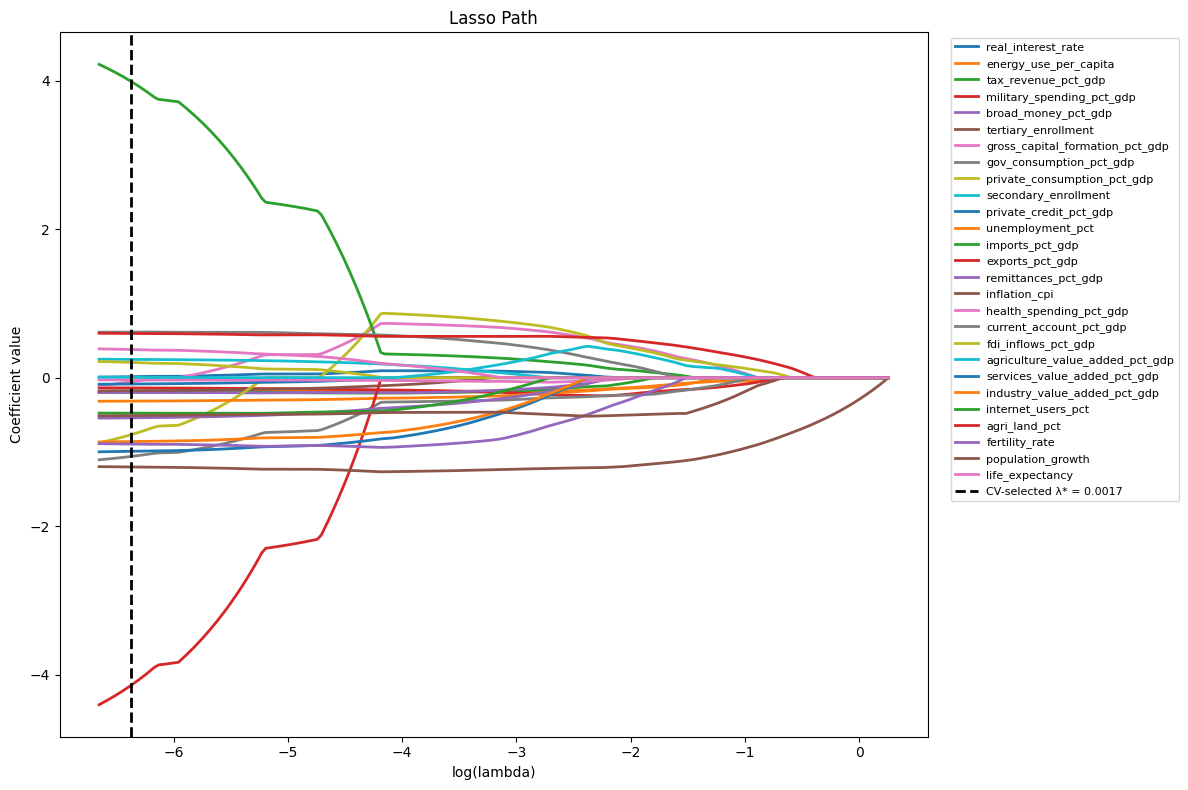

=== Step 1.3: Lasso Path ===
First predictor to enter the model: inflation_cpi

Written response:
The first predictor to enter the model is inflation_cpi, meaning it has the strongest unconditional
signal along the Lasso path. More generally, a variable being zeroed out by Lasso does not mean it is
unimportant in the real world; it may be conditionally redundant because other correlated WDI indicators
already capture similar information. In highly correlated datasets, Lasso tends to select one representative
variable and suppress close substitutes.



In [7]:
alphas_path, coefs_path, _ = lasso_path(
    X_train_scaled.values,
    y_train_reg.values,
    alphas=lasso_cv.alphas_
)

idx_star = int(np.argmin(np.abs(alphas_path - lasso_cv.alpha_)))
active_at_star = np.abs(coefs_path[:, idx_star]) > 1e-8

entry_alpha = {}
for i, feat in enumerate(X.columns):
    nz = np.abs(coefs_path[i]) > 1e-8
    entry_alpha[feat] = float(np.max(alphas_path[nz])) if np.any(nz) else 0.0

first_feature = max(entry_alpha, key=entry_alpha.get)

plt.figure(figsize=(12, 8))
for i, feat in enumerate(X.columns):
    if active_at_star[i]:
        plt.plot(np.log(alphas_path), coefs_path[i], linewidth=2, label=feat)
    else:
        plt.plot(np.log(alphas_path), coefs_path[i], color="lightgray", alpha=0.8, linewidth=1)

plt.axvline(np.log(lasso_cv.alpha_), color="black", linestyle="--", linewidth=2,
            label=f"CV-selected λ* = {lasso_cv.alpha_:.4f}")

plt.xlabel("log(lambda)")
plt.ylabel("Coefficient value")
plt.title("Lasso Path")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

print("=== Step 1.3: Lasso Path ===")
print("First predictor to enter the model:", first_feature)

if "life_expectancy" not in selected_features:
    response_13 = f"""
Written response:
The first predictor to enter the model is {first_feature}, meaning it has the strongest unconditional
signal along the Lasso path. If Lasso zeroed out life_expectancy, that does not mean health is irrelevant:
it means life_expectancy may be conditionally redundant once correlated development indicators are already
in the model. With correlated WDI variables, Lasso often keeps one representative predictor and drops others
that carry overlapping information.
"""
else:
    response_13 = f"""
Written response:
The first predictor to enter the model is {first_feature}, meaning it has the strongest unconditional
signal along the Lasso path. More generally, a variable being zeroed out by Lasso does not mean it is
unimportant in the real world; it may be conditionally redundant because other correlated WDI indicators
already capture similar information. In highly correlated datasets, Lasso tends to select one representative
variable and suppress close substitutes.
"""
print(response_13)

In [8]:
X_train_sel = X_train_scaled[selected_features].copy()
X_test_sel = X_test_scaled[selected_features].copy()

lpm_model = LinearRegression()
lpm_model.fit(X_train_sel, y_train_clf)

lpm_test_pred = lpm_model.predict(X_test_sel)

below_zero = int((lpm_test_pred < 0).sum())
above_one = int((lpm_test_pred > 1).sum())

print("=== Step 2.1: Linear Probability Model ===")
print(f"Predictions below 0 : {below_zero}")
print(f"Predictions above 1 : {above_one}")

response_21 = f"""
Written response:
The LPM produces {below_zero} predicted probabilities below 0 and {above_one} above 1, which shows that
it is not respecting the logical bounds of probability. A value like -12% probability of crisis is not just
ugly formatting—it is meaningless for decision-making, because the IMF cannot interpret or compare an impossible
probability when deciding whether to deploy scarce crisis missions.
"""
print(response_21)

=== Step 2.1: Linear Probability Model ===
Predictions below 0 : 19
Predictions above 1 : 4

Written response:
The LPM produces 19 predicted probabilities below 0 and 4 above 1, which shows that
it is not respecting the logical bounds of probability. A value like -12% probability of crisis is not just
ugly formatting—it is meaningless for decision-making, because the IMF cannot interpret or compare an impossible
probability when deciding whether to deploy scarce crisis missions.



In [9]:
try:
    logit = LogisticRegression(
        penalty=None,
        solver="lbfgs",
        max_iter=5000,
        random_state=SEED
    )
    logit.fit(X_train_sel, y_train_clf)
except Exception:
    logit = LogisticRegression(
        penalty="none",
        solver="lbfgs",
        max_iter=5000,
        random_state=SEED
    )
    logit.fit(X_train_sel, y_train_clf)

y_prob = logit.predict_proba(X_test_sel)[:, 1]

coef_table = pd.DataFrame({
    "feature": selected_features,
    "beta": logit.coef_.ravel(),
    "odds_ratio": np.exp(logit.coef_.ravel())
})

coef_table["abs_log_odds_ratio"] = np.abs(np.log(coef_table["odds_ratio"]))
coef_table = coef_table.sort_values("abs_log_odds_ratio", ascending=False).reset_index(drop=True)

strongest_predictor = coef_table.loc[0, "feature"]
strongest_or = coef_table.loc[0, "odds_ratio"]

print("=== Step 2.2: Logistic Regression ===")
print("Intercept (beta_0):", float(logit.intercept_[0]))
print("\nOdds ratio table (sorted):")
print(coef_table.round(4))

print("\nPredicted probability range:")
print("Min:", y_prob.min())
print("Max:", y_prob.max())

if strongest_or >= 1:
    plain_english = f"A one standard-deviation increase in {strongest_predictor} multiplies the odds of crisis by {strongest_or:.2f}, holding all else constant."
else:
    plain_english = f"A one standard-deviation increase in {strongest_predictor} multiplies the odds of crisis by {strongest_or:.2f}, holding all else constant."

print("\nWritten response:")
print(plain_english)

=== Step 2.2: Logistic Regression ===
Intercept (beta_0): -2.6397292139528568

Odds ratio table (sorted):
                            feature    beta  odds_ratio  abs_log_odds_ratio
0                     inflation_cpi  2.4912     12.0758              2.4912
1                   imports_pct_gdp -2.3990      0.0908              2.3990
2                   exports_pct_gdp  2.0315      7.6252              2.0315
3                   life_expectancy -1.9429      0.1433              1.9429
4                internet_users_pct  1.4324      4.1887              1.4324
5           current_account_pct_gdp -1.2141      0.2970              1.2141
6                 population_growth  0.9852      2.6783              0.9852
7                    fertility_rate -0.9652      0.3809              0.9652
8              secondary_enrollment -0.8976      0.4076              0.8976
9      services_value_added_pct_gdp  0.8761      2.4016              0.8761
10              remittances_pct_gdp  0.8365      2.3083   

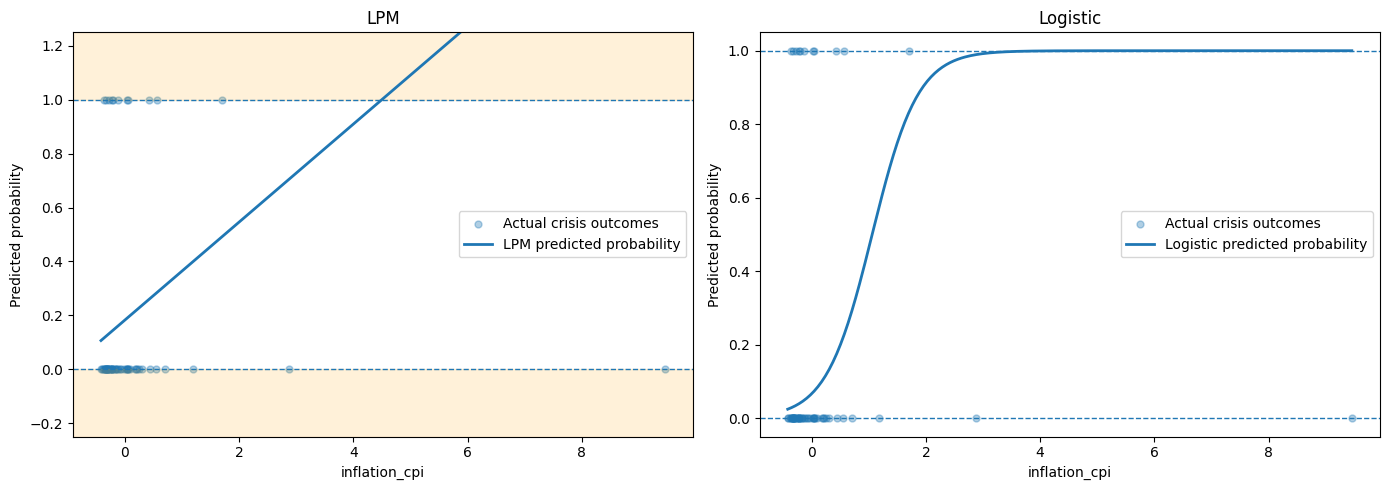

In [10]:
x_name = strongest_predictor
x_bg = X_test_sel[x_name].values
y_bg = y_test_clf.values

grid = np.linspace(x_bg.min(), x_bg.max(), 300)

X_grid = pd.DataFrame(
    np.zeros((len(grid), len(selected_features))),
    columns=selected_features
)
X_grid[x_name] = grid

lpm_curve = lpm_model.predict(X_grid)
logit_curve = logit.predict_proba(X_grid)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LPM panel
axes[0].scatter(x_bg, y_bg, alpha=0.35, s=25, label="Actual crisis outcomes")
axes[0].plot(grid, lpm_curve, linewidth=2, label="LPM predicted probability")
axes[0].axhspan(-0.25, 0, color="orange", alpha=0.15)
axes[0].axhspan(1, 1.25, color="orange", alpha=0.15)
axes[0].axhline(0, linestyle="--", linewidth=1)
axes[0].axhline(1, linestyle="--", linewidth=1)
axes[0].set_ylim(-0.25, 1.25)
axes[0].set_title("LPM")
axes[0].set_xlabel(x_name)
axes[0].set_ylabel("Predicted probability")
axes[0].legend()

# Logistic panel
axes[1].scatter(x_bg, y_bg, alpha=0.35, s=25, label="Actual crisis outcomes")
axes[1].plot(grid, logit_curve, linewidth=2, label="Logistic predicted probability")
axes[1].axhline(0, linestyle="--", linewidth=1)
axes[1].axhline(1, linestyle="--", linewidth=1)
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_title("Logistic")
axes[1].set_xlabel(x_name)
axes[1].set_ylabel("Predicted probability")
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
naive_pred = np.zeros(len(y_test_clf), dtype=int)

naive_acc = accuracy_score(y_test_clf, naive_pred)
naive_recall = recall_score(y_test_clf, naive_pred, zero_division=0)

y_pred_05 = (y_prob >= 0.50).astype(int)

logit_acc = accuracy_score(y_test_clf, y_pred_05)
logit_recall = recall_score(y_test_clf, y_pred_05, zero_division=0)

test_base_rate = y_test_clf.mean()

print("=== Step 3.1: Accuracy Paradox ===")
print(f"Test crisis base rate        : {test_base_rate:.4f}")
print(f"Naive baseline accuracy      : {naive_acc:.4f}")
print(f"Naive baseline recall        : {naive_recall:.4f}")
print(f"Logistic accuracy @ tau=0.5  : {logit_acc:.4f}")
print(f"Logistic recall @ tau=0.5    : {logit_recall:.4f}")

response_31 = f"""
Written response:
Because crises are relatively rare in the test set, accuracy by itself can be misleading: a model that
always predicts "no crisis" can still look good on accuracy while completely failing to catch actual crises.
In this dataset, the naive model gets accuracy of {naive_acc:.4f} but recall of only {naive_recall:.4f},
so reporting accuracy alone would mislead the Division Chief about operational usefulness.
"""
print(response_31)

=== Step 3.1: Accuracy Paradox ===
Test crisis base rate        : 0.1833
Naive baseline accuracy      : 0.8167
Naive baseline recall        : 0.0000
Logistic accuracy @ tau=0.5  : 0.8167
Logistic recall @ tau=0.5    : 0.4545

Written response:
Because crises are relatively rare in the test set, accuracy by itself can be misleading: a model that
always predicts "no crisis" can still look good on accuracy while completely failing to catch actual crises.
In this dataset, the naive model gets accuracy of 0.8167 but recall of only 0.0000,
so reporting accuracy alone would mislead the Division Chief about operational usefulness.



=== Step 3.2: Confusion Matrix ===


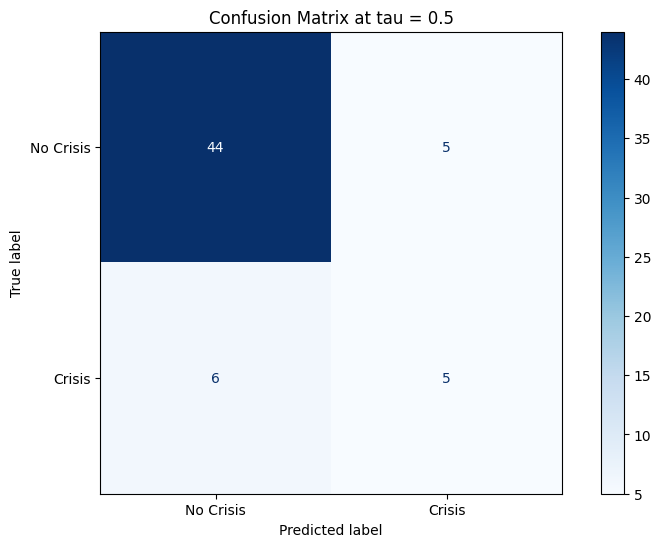

Classification report:

              precision    recall  f1-score   support

   No Crisis       0.88      0.90      0.89        49
      Crisis       0.50      0.45      0.48        11

    accuracy                           0.82        60
   macro avg       0.69      0.68      0.68        60
weighted avg       0.81      0.82      0.81        60

TP: 5
FN: 6
FP: 5
TN: 44

Written response:
In the IMF setting, a False Negative is more costly than a False Positive because missing a real crisis can
trigger sovereign default, contagion, and much larger emergency lending needs. That asymmetry means the Division
Chief should lean toward prioritizing recall over precision, even though some false alarms may still be unavoidable.



In [12]:
cm = confusion_matrix(y_test_clf, y_pred_05)
tn, fp, fn, tp = cm.ravel()

print("=== Step 3.2: Confusion Matrix ===")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Crisis", "Crisis"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix at tau = 0.5")
plt.show()

print("Classification report:\n")
print(classification_report(y_test_clf, y_pred_05, target_names=["No Crisis", "Crisis"], zero_division=0))

print(f"TP: {tp}")
print(f"FN: {fn}")
print(f"FP: {fp}")
print(f"TN: {tn}")

response_32 = f"""
Written response:
In the IMF setting, a False Negative is more costly than a False Positive because missing a real crisis can
trigger sovereign default, contagion, and much larger emergency lending needs. That asymmetry means the Division
Chief should lean toward prioritizing recall over precision, even though some false alarms may still be unavoidable.
"""
print(response_32)

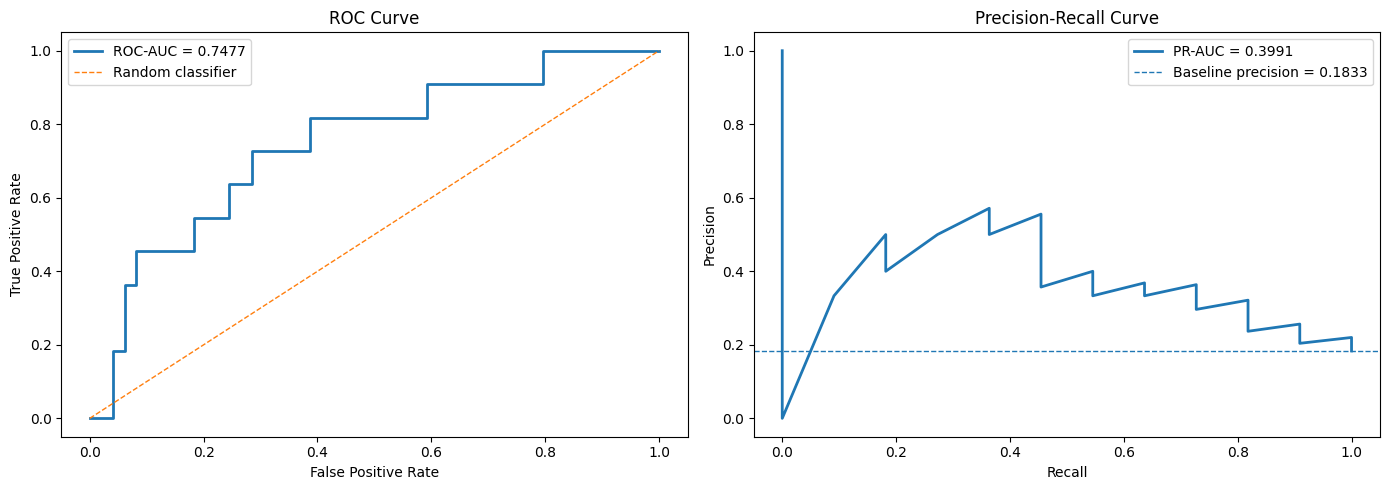


Written response:
ROC-AUC is often higher than PR-AUC in imbalanced datasets because ROC rewards the model for correctly handling
the many true negatives, while the PR curve ignores true negatives completely and focuses on the harder crisis-detection task.
For the IMF's mission, the PR curve is usually more informative because the real question is how much precision the model can
maintain while trying to catch rare crises.



In [13]:
fpr, tpr, _ = roc_curve(y_test_clf, y_prob)
roc_auc = roc_auc_score(y_test_clf, y_prob)

precision_curve, recall_curve, _ = precision_recall_curve(y_test_clf, y_prob)
pr_auc = average_precision_score(y_test_clf, y_prob)

base_precision = y_test_clf.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
axes[0].plot(fpr, tpr, linewidth=2, label=f"ROC-AUC = {roc_auc:.4f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random classifier")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

# PR
axes[1].plot(recall_curve, precision_curve, linewidth=2, label=f"PR-AUC = {pr_auc:.4f}")
axes[1].axhline(base_precision, linestyle="--", linewidth=1, label=f"Baseline precision = {base_precision:.4f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

response_33 = f"""
Written response:
ROC-AUC is often higher than PR-AUC in imbalanced datasets because ROC rewards the model for correctly handling
the many true negatives, while the PR curve ignores true negatives completely and focuses on the harder crisis-detection task.
For the IMF's mission, the PR curve is usually more informative because the real question is how much precision the model can
maintain while trying to catch rare crises.
"""
print(response_33)

=== Step 3.4: Threshold Analysis ===
Capacity-constrained threshold:
threshold    0.9100
n_flagged    5.0000
precision    0.4000
recall       0.1818
f1           0.2500
Name: 90, dtype: float64

F1-optimal threshold:
threshold    0.7000
n_flagged    9.0000
precision    0.5556
recall       0.4545
f1           0.5000
Name: 69, dtype: float64


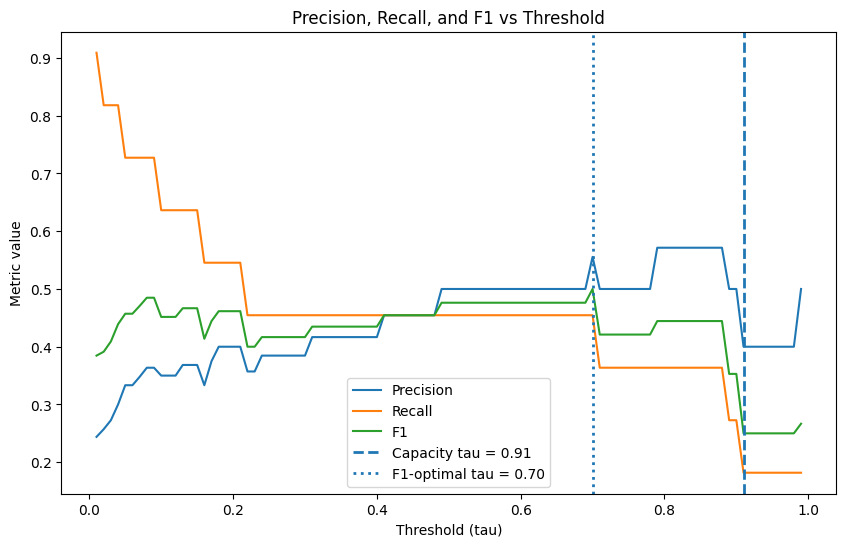


Written response:
I recommend tau = 0.91, the lowest threshold that keeps the IMF within its 5-mission quarterly capacity.
At this operating point, the model flags 5 countries and achieves recall of
0.1818, meaning it would catch 2 of the 11 crisis countries in the
test set and miss 9. The F1-optimal threshold is 0.70; if adopted, it would flag
9 countries. Because the IMF faces a hard deployment constraint, I would prioritize
the capacity-constrained threshold even if it sacrifices some recall.



In [14]:
thresholds = np.round(np.arange(0.01, 1.00, 0.01), 2)

rows = []
for t in thresholds:
    pred = (y_prob >= t).astype(int)
    rows.append({
        "threshold": t,
        "n_flagged": int(pred.sum()),
        "precision": precision_score(y_test_clf, pred, zero_division=0),
        "recall": recall_score(y_test_clf, pred, zero_division=0),
        "f1": f1_score(y_test_clf, pred, zero_division=0)
    })

threshold_df = pd.DataFrame(rows)

capacity_row = threshold_df.loc[threshold_df["n_flagged"] <= 5].iloc[0]
f1_row = threshold_df.loc[threshold_df["f1"].idxmax()]

cap_tau = float(capacity_row["threshold"])
f1_tau = float(f1_row["threshold"])

cap_pred = (y_prob >= cap_tau).astype(int)
cap_tp = int(((cap_pred == 1) & (y_test_clf.values == 1)).sum())
cap_total_crises = int(y_test_clf.sum())
cap_missed = cap_total_crises - cap_tp

print("=== Step 3.4: Threshold Analysis ===")
print("Capacity-constrained threshold:")
print(capacity_row.round(4))
print("\nF1-optimal threshold:")
print(f1_row.round(4))

plt.figure(figsize=(10, 6))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.axvline(cap_tau, linestyle="--", linewidth=2, label=f"Capacity tau = {cap_tau:.2f}")
plt.axvline(f1_tau, linestyle=":", linewidth=2, label=f"F1-optimal tau = {f1_tau:.2f}")
plt.xlabel("Threshold (tau)")
plt.ylabel("Metric value")
plt.title("Precision, Recall, and F1 vs Threshold")
plt.legend()
plt.show()

memo_34 = f"""
Written response:
I recommend tau = {cap_tau:.2f}, the lowest threshold that keeps the IMF within its 5-mission quarterly capacity.
At this operating point, the model flags {int(capacity_row['n_flagged'])} countries and achieves recall of
{capacity_row['recall']:.4f}, meaning it would catch {cap_tp} of the {cap_total_crises} crisis countries in the
test set and miss {cap_missed}. The F1-optimal threshold is {f1_tau:.2f}; if adopted, it would flag
{int(f1_row['n_flagged'])} countries. Because the IMF faces a hard deployment constraint, I would prioritize
the capacity-constrained threshold even if it sacrifices some recall.
"""
print(memo_34)

## Task 4.1: P.R.I.M.E. Prompt

**Prep:** I am working in Google Colab on an IMF early-warning-system assignment. I already have the following Python objects in memory: `X_train_scaled` (pandas DataFrame of standardized predictors), `y_train_reg` (continuous GDP per capita growth outcome), and `X.columns` as the full predictor set.

**Request:** Write Python code that performs a bootstrap stability analysis for Lasso feature selection. The code must:
1. Draw 200 bootstrap resamples with replacement from the training data.
2. Fit `LassoCV(cv=5, random_state=...)` on each bootstrap sample.
3. Record whether each predictor receives a non-zero coefficient in each resample.
4. Compute the selection frequency for every predictor.
5. Produce a horizontal bar chart ranking predictors by selection frequency.
6. Add a vertical dashed reference line at 50%.

**Iterate:** Keep the code clear, compact, and fully runnable in one Colab cell. Use only pandas, numpy, matplotlib, and scikit-learn. Do not use placeholder variables or pseudocode.

**Mechanism Check:** Make sure the code uses the already-existing variables exactly as named: `X_train_scaled`, `y_train_reg`, and the predictor names from `X_train_scaled.columns`.

**Evaluate:** After the chart, print two lists:
- stable predictors = selected more than 80% of the time
- fragile predictors = selected less than 30% of the time

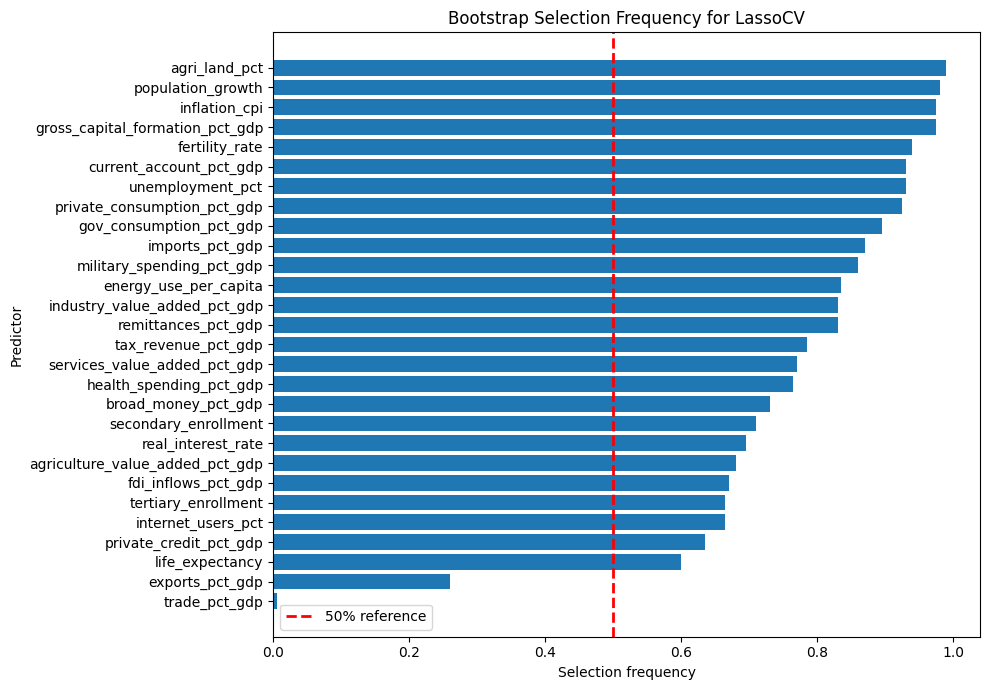

Stable predictors (>80%):
['remittances_pct_gdp', 'industry_value_added_pct_gdp', 'energy_use_per_capita', 'military_spending_pct_gdp', 'imports_pct_gdp', 'gov_consumption_pct_gdp', 'private_consumption_pct_gdp', 'unemployment_pct', 'current_account_pct_gdp', 'fertility_rate', 'gross_capital_formation_pct_gdp', 'inflation_cpi', 'population_growth', 'agri_land_pct']

Fragile predictors (<30%):
['trade_pct_gdp', 'exports_pct_gdp']

Written response:
Stable predictors are those selected in more than 80% of bootstrap samples, while fragile predictors appear in fewer
than 30%. When selection frequencies vary a lot across resamples, that suggests many WDI indicators are correlated and
can substitute for one another, so the exact Lasso model depends on which countries happen to be in the sample.



In [15]:
n_boot = 200
boot_selection = []
boot_alpha = []

for b in range(n_boot):
    sample_idx = np.random.choice(X_train_scaled.index, size=len(X_train_scaled), replace=True)
    X_b = X_train_scaled.loc[sample_idx]
    y_b = y_train_reg.loc[sample_idx]

    model_b = LassoCV(cv=5, random_state=SEED + b, max_iter=20000, n_alphas=200)
    model_b.fit(X_b, y_b)

    boot_selection.append((np.abs(model_b.coef_) > 1e-8).astype(int))
    boot_alpha.append(model_b.alpha_)

selection_df = pd.DataFrame(boot_selection, columns=X_train_scaled.columns)
selection_freq = selection_df.mean().sort_values(ascending=True)

plt.figure(figsize=(10, max(6, len(selection_freq) * 0.25)))
plt.barh(selection_freq.index, selection_freq.values)
plt.axvline(0.50, color="red", linestyle="--", linewidth=2, label="50% reference")
plt.xlabel("Selection frequency")
plt.ylabel("Predictor")
plt.title("Bootstrap Selection Frequency for LassoCV")
plt.legend()
plt.tight_layout()
plt.show()

stable_predictors = selection_freq[selection_freq > 0.80].index.tolist()
fragile_predictors = selection_freq[selection_freq < 0.30].index.tolist()

print("Stable predictors (>80%):")
print(stable_predictors)

print("\nFragile predictors (<30%):")
print(fragile_predictors)

response_41 = f"""
Written response:
Stable predictors are those selected in more than 80% of bootstrap samples, while fragile predictors appear in fewer
than 30%. When selection frequencies vary a lot across resamples, that suggests many WDI indicators are correlated and
can substitute for one another, so the exact Lasso model depends on which countries happen to be in the sample.
"""
print(response_41)

## Task 4.2: P.R.I.M.E. Prompt

**Prep:** I am working in Google Colab on an IMF early-warning-system assignment. I already have `y_test_clf` (true crisis labels for the test set) and `y_prob` (predicted crisis probabilities from a logistic regression model).

**Request:** Write Python code that performs cost-sensitive threshold optimization for crisis detection. The code must:
1. Sweep thresholds from 0.01 to 0.99 in steps of 0.01.
2. At each threshold, convert probabilities into predicted labels.
3. Compute the confusion matrix counts.
4. Compute expected cost using:
   - False Negative cost = $50,000,000,000
   - False Positive cost = $2,000,000
   - Total expected cost = FN * 50B + FP * 2M
5. Plot expected cost as a function of threshold.
6. Identify and annotate the cost-minimizing threshold.

**Iterate:** Keep the code fully runnable in one Colab cell and use only numpy, pandas, matplotlib, and scikit-learn.

**Mechanism Check:** Use the existing variable names exactly as written: `y_test_clf` and `y_prob`.

**Evaluate:** After plotting, print the cost-minimizing threshold and compare it with the capacity-constrained threshold and the F1-optimal threshold computed earlier.

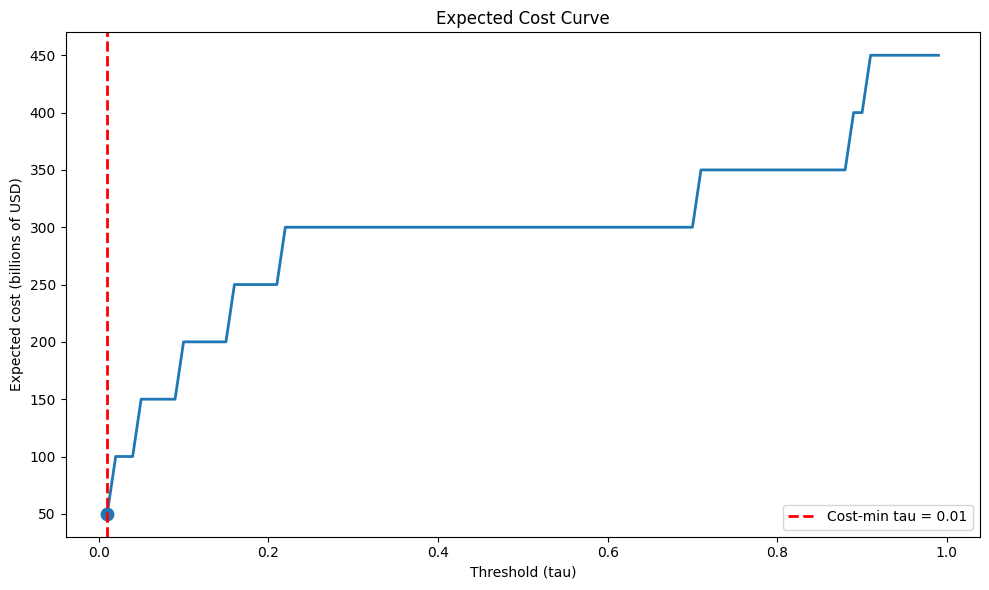

=== Task 4.2: Cost-sensitive threshold ===
threshold        1.000000e-02
tn               1.800000e+01
fp               3.100000e+01
fn               1.000000e+00
tp               1.000000e+01
expected_cost    5.006200e+10
Name: 0, dtype: float64

Written response:
The cost-minimizing threshold is tau = 0.01. It differs from the F1-optimal threshold (0.70)
because F1 balances precision and recall symmetrically, while the IMF's loss function is extremely asymmetric:
a false negative costs far more than a false positive. It can also differ from the capacity-constrained threshold
(0.91) because operational staffing limits and dollar-loss minimization are not the same objective.
If the IMF must obey the 5-mission cap, I would still recommend the capacity-constrained threshold; otherwise,
the cost-minimizing threshold is the better choice under the stated loss function.



In [16]:
cost_fn = 50_000_000_000   # 50B
cost_fp = 2_000_000        # 2M

cost_rows = []
for t in thresholds:
    pred = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_clf, pred).ravel()
    total_cost = fn * cost_fn + fp * cost_fp

    cost_rows.append({
        "threshold": t,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "expected_cost": float(total_cost)
    })

cost_df = pd.DataFrame(cost_rows)
best_cost_row = cost_df.loc[cost_df["expected_cost"].idxmin()]

best_cost_tau = float(best_cost_row["threshold"])
best_cost_value = float(best_cost_row["expected_cost"])

plt.figure(figsize=(10, 6))
plt.plot(cost_df["threshold"], cost_df["expected_cost"] / 1e9, linewidth=2)
plt.axvline(best_cost_tau, color="red", linestyle="--", linewidth=2, label=f"Cost-min tau = {best_cost_tau:.2f}")
plt.scatter([best_cost_tau], [best_cost_value / 1e9], s=80)
plt.xlabel("Threshold (tau)")
plt.ylabel("Expected cost (billions of USD)")
plt.title("Expected Cost Curve")
plt.legend()
plt.tight_layout()
plt.show()

print("=== Task 4.2: Cost-sensitive threshold ===")
print(best_cost_row)

response_42 = f"""
Written response:
The cost-minimizing threshold is tau = {best_cost_tau:.2f}. It differs from the F1-optimal threshold ({f1_tau:.2f})
because F1 balances precision and recall symmetrically, while the IMF's loss function is extremely asymmetric:
a false negative costs far more than a false positive. It can also differ from the capacity-constrained threshold
({cap_tau:.2f}) because operational staffing limits and dollar-loss minimization are not the same objective.
If the IMF must obey the 5-mission cap, I would still recommend the capacity-constrained threshold; otherwise,
the cost-minimizing threshold is the better choice under the stated loss function.
"""
print(response_42)